# 인터넷전문은행 중·저신용자 대출 규제 실효성 분석

분석 질문 4개를 검증하기 위한 코드입니다. 섹션별로 순서대로 실행하세요.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['font.family'] = 'Malgun Gothic'  # Windows
# plt.rcParams['font.family'] = 'AppleGothic'  # macOS


## 1. 데이터 로드

In [2]:
DATA_PATH = "data/데이터북_v4.xlsx"

df_credit = pd.read_excel(DATA_PATH, sheet_name="월별_평균신용점수", skiprows=3)
df_rate = pd.read_excel(DATA_PATH, sheet_name="월별_고금리비중", skiprows=3)

df_credit['취급월'] = pd.to_datetime(df_credit['취급월'])
df_rate['취급월'] = pd.to_datetime(df_rate['취급월'])

df_credit.head()


,공시년월,취급월,은행,평균금리,서민금융제외평균금리,평균신용점수
0,2023-08,2023-07-01,케이뱅크,7.44,7.55,869
1,2023-08,2023-07-01,카카오뱅크,6.33,6.37,867
2,2023-08,2023-07-01,토스뱅크,6.77,6.84,918
3,2023-09,2023-08-01,케이뱅크,6.61,6.10,810
4,2023-09,2023-08-01,카카오뱅크,6.20,6.16,880


In [3]:
df_rate.head()


,공시년월,취급월,은행,고금리8퍼센트이상비중,10퍼센트이상비중,평균금리
0,2023-01,2022-12-01,케이뱅크,53.4,6.6,8.14
1,2023-01,2022-12-01,카카오뱅크,49.7,17.6,8.04
2,2023-01,2022-12-01,토스뱅크,42.3,26.0,8.47
3,2023-02,2023-01-01,케이뱅크,20.7,1.4,6.90
4,2023-02,2023-01-01,카카오뱅크,17.7,4.7,6.32


## 2. 데이터 기본 정보 확인
- 기간, 컬럼, 결측치 여부 확인

**확인 결과**: `월별_평균신용점수` 108행(36개월×3사, 2023-07~2026-06), `월별_고금리비중` 127행(2022-12~2026-06). 컬럼 자체의 결측치(NaN)는 없으나, 아래에서 **월 커버리지 결측**을 확인함.

In [4]:
for name, df in [("월별_평균신용점수", df_credit), ("월별_고금리비중", df_rate)]:
    print(f"=== {name} ===")
    print("행 수:", len(df))
    print("컬럼:", list(df.columns))
    print("기간:", df['취급월'].min(), "~", df['취급월'].max())
    print("컬럼 결측치:\n", df.isna().sum())
    print()


=== 월별_평균신용점수 ===
행 수: 108
컬럼: ['공시년월', '취급월', '은행', '평균금리', '서민금융제외평균금리', '평균신용점수']
기간: 2023-07-01 00:00:00 ~ 2026-06-01 00:00:00
컬럼 결측치:
 공시년월          0
취급월           0
은행            0
평균금리          0
서민금융제외평균금리    0
평균신용점수        0
dtype: int64

=== 월별_고금리비중 ===
행 수: 127
컬럼: ['공시년월', '취급월', '은행', '고금리8퍼센트이상비중', '10퍼센트이상비중', '평균금리']
기간: 2022-12-01 00:00:00 ~ 2026-06-01 00:00:00
컬럼 결측치:
 공시년월           0
취급월            0
은행             0
고금리8퍼센트이상비중    0
10퍼센트이상비중      0
평균금리           0
dtype: int64



In [5]:
# 은행별 월 커버리지 확인 (빠진 달 탐지)
for name, df in [("신용점수", df_credit), ("고금리비중", df_rate)]:
    for bank in df['은행'].unique():
        sub = df[df['은행'] == bank].sort_values('취급월')
        full_range = pd.date_range(sub['취급월'].min(), sub['취급월'].max(), freq='MS')
        missing = sorted(set(full_range) - set(sub['취급월']))
        if missing:
            print(f"[{name}] {bank} 결측 월:", missing)


[고금리비중] 토스뱅크 결측 월: [Timestamp('2023-11-01 00:00:00'), Timestamp('2024-11-01 00:00:00')]


## 3. 결측치 / 이상치 처리

**처리 기준 (근거 포함)**

1. **결측치**: `월별_고금리비중`에서 토스뱅크 2023-11, 2024-11 두 달이 빠져 있음(전체 127행 중 2행, 약 1.6%). 앞뒤 인접월이 존재하므로 **선형보간(interpolate)**으로 채운다. 단, 이 두 달의 값은 실제 관측치가 아니라는 점을 리포트 한계점에 명시한다.
2. **이상치**: 토스뱅크 2026-06 데이터가 전월 대비 급변(평균신용점수 930→834, 고금리비중 5.1%→31.7%, 평균금리 5.66→7.80%)함. 통계적으로는 이상치 후보로 잡히지만, **측정 오류가 아니라 실제 관측치로 판단**하여 삭제하지 않고 유지한다. 원인 해석은 6절 인사이트에서 별도로 다룬다.

In [6]:
# 이상치 스캔: 은행별 평균신용점수, 평균금리의 전월 대비 변화폭이 큰 지점 확인
df_credit_sorted = df_credit.sort_values(['은행', '취급월']).copy()
df_credit_sorted['금리_변화'] = df_credit_sorted.groupby('은행')['평균금리'].diff()
df_credit_sorted['신용점수_변화'] = df_credit_sorted.groupby('은행')['평균신용점수'].diff()

threshold_rate = df_credit_sorted['금리_변화'].std() * 2
threshold_score = df_credit_sorted['신용점수_변화'].std() * 2

outliers = df_credit_sorted[
    (df_credit_sorted['금리_변화'].abs() > threshold_rate) |
    (df_credit_sorted['신용점수_변화'].abs() > threshold_score)
]
outliers[['취급월', '은행', '평균금리', '금리_변화', '평균신용점수', '신용점수_변화']]


,취급월,은행,평균금리,금리_변화,평균신용점수,신용점수_변화
52,2024-12-01,카카오뱅크,5.54,-0.03,811,-98.0
55,2025-01-01,카카오뱅크,4.88,-0.66,929,118.0
88,2025-12-01,카카오뱅크,5.97,1.13,834,-82.0
3,2023-08-01,케이뱅크,6.61,-0.83,810,-59.0
6,2023-09-01,케이뱅크,5.73,-0.88,813,3.0
33,2024-06-01,케이뱅크,6.11,0.74,821,-87.0
54,2025-01-01,케이뱅크,4.94,-0.82,928,120.0
107,2026-06-01,토스뱅크,7.80,2.14,834,-96.0


In [7]:
# 결측월 보간 처리 (고금리비중, 토스뱅크)
df_rate_wide_raw = df_rate.pivot(index='취급월', columns='은행', values='고금리8퍼센트이상비중')
df_rate_wide_raw = df_rate_wide_raw.asfreq('MS')
df_rate_wide = df_rate_wide_raw.interpolate(method='linear')

print("보간 전 결측 개수:\n", df_rate_wide_raw.isna().sum())
print("\n보간 후 결측 개수:\n", df_rate_wide.isna().sum())
df_rate_wide.loc['2023-10':'2023-12']


보간 전 결측 개수:
 은행
카카오뱅크    0
케이뱅크     0
토스뱅크     2
dtype: int64

보간 후 결측 개수:
 은행
카카오뱅크    0
케이뱅크     0
토스뱅크     0
dtype: int64


은행,카카오뱅크,케이뱅크,토스뱅크
취급월,,,
2023-10-01,26.6,7.9,23.4
2023-11-01,28.3,10.4,20.1
2023-12-01,20.7,8.6,16.8


## 4. 시계열 분석 기법 적용

**적용 기법 및 선택 이유**
- **3개월 이동평균**: 월별 단기 변동(노이즈)을 완화해서 장기 추세를 더 명확히 보기 위해
- **전월 대비 변화율(%)**: 절대 스케일이 다른 신용점수(800~950점대)와 고금리비중(0~50%대)을 같은 기준(변화율)으로 비교하기 위해. 단, 고금리비중이 0%에 가까운 달은 분모가 0에 가까워져 변화율이 극단적으로 커지거나(`inf`) 계산이 불가능해질 수 있어 `inf/-inf`는 제외 처리한다.
- **고금리비중 전월 대비 %p 변화**: 상대 변화율만으로는 낮은 기준값에서 변화가 과장되므로, 실제 비중 변화 크기를 함께 보기 위해 %p 변화도 계산한다.
- **스프레드(서민금융제외평균금리-평균금리)**: 서민금융(보증부 상품) 포함 여부에 따른 금리 차이로 위험이전 경로 존재 여부를 확인하기 위해

In [8]:
# 4-1. 3개월 이동평균
df_credit_wide = df_credit.pivot(index='취급월', columns='은행', values='평균신용점수').asfreq('MS')
df_credit_ma = df_credit_wide.rolling(window=3).mean()

df_rate_ma = df_rate_wide.rolling(window=3).mean()

df_credit_ma.tail()


은행,카카오뱅크,케이뱅크,토스뱅크
취급월,,,
2026-02-01,875.000000,898.000000,907.333333
2026-03-01,893.666667,889.333333,926.000000
2026-04-01,888.000000,892.333333,924.333333
2026-05-01,895.000000,895.666667,926.666667
2026-06-01,908.666667,891.333333,894.666667


In [9]:
# 4-2. 전월 대비 변화율 (inf/-inf 제외)
df_credit_pct = df_credit_wide.pct_change() * 100
df_rate_pct = df_rate_wide.pct_change() * 100

# 분모가 0에 가까워 발생하는 inf/-inf는 해석 불가능하므로 NaN 처리
n_inf_before = np.isinf(df_rate_pct.values).sum()
df_rate_pct = df_rate_pct.replace([np.inf, -np.inf], np.nan)
print(f"고금리비중 변화율에서 제외한 inf/-inf 개수: {n_inf_before}")

df_credit_pct.tail()


고금리비중 변화율에서 제외한 inf/-inf 개수: 1


은행,카카오뱅크,케이뱅크,토스뱅크
취급월,,,
2026-02-01,0.111732,-0.337458,-0.216216
2026-03-01,-0.669643,0.790068,0.758397
2026-04-01,-1.348315,0.559910,-1.075269
2026-05-01,4.441913,-0.222717,1.086957
2026-06-01,1.526718,-1.785714,-10.322581


In [10]:
# 4-3. 고금리비중 전월 대비 %p 변화 (절대 변화폭)
df_rate_ppt_change = df_rate_wide.diff()
df_rate_ppt_change.tail()


은행,카카오뱅크,케이뱅크,토스뱅크
취급월,,,
2026-02-01,1.5,0.0,0.3
2026-03-01,2.3,0.1,-0.7
2026-04-01,2.8,-0.3,2.2
2026-05-01,-3.8,0.0,-1.8
2026-06-01,-1.6,0.9,26.6


In [11]:
# 4-4. 스프레드 (서민금융제외평균금리 - 평균금리)
df_credit['스프레드'] = df_credit['서민금융제외평균금리'] - df_credit['평균금리']
df_spread_wide = df_credit.pivot(index='취급월', columns='은행', values='스프레드')

# 은행별 스프레드 요약 (리포트 5.4 표와 대조용)
summary = pd.DataFrame({
    '최소': df_spread_wide.min(),
    '최대': df_spread_wide.max(),
    '음수달수': (df_spread_wide < 0).sum(),
    '양수달수': (df_spread_wide > 0).sum(),
})
summary


,최소,최대,음수달수,양수달수
은행,,,,
카카오뱅크,-0.41,0.99,28,8
케이뱅크,-1.12,3.24,29,7
토스뱅크,-0.23,1.11,8,26


## 5. 시각화

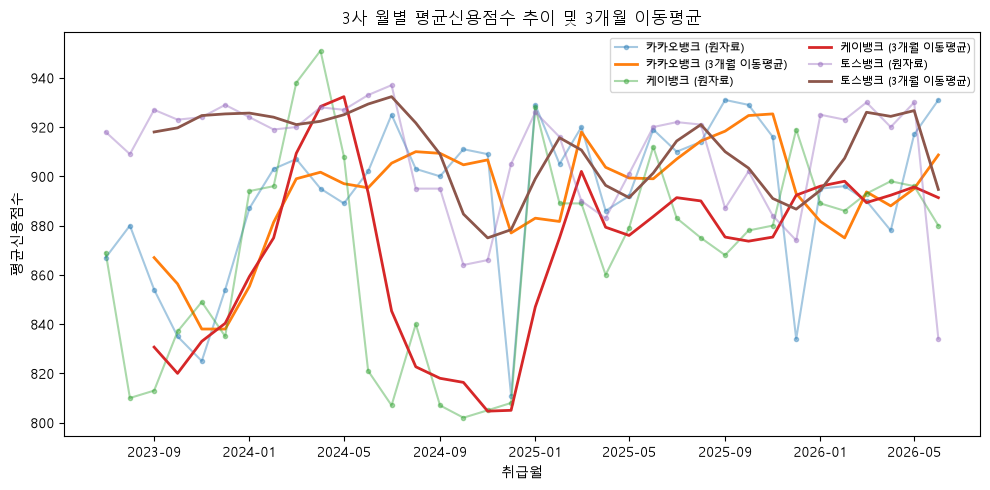

In [12]:
# 시각화 1: 질문 1 - 3사 평균신용점수 원자료 + 3개월 이동평균
fig, ax = plt.subplots(figsize=(10, 5))
for bank in df_credit_wide.columns:
    ax.plot(df_credit_wide.index, df_credit_wide[bank], marker='o', markersize=3, alpha=0.4, label=f'{bank} (원자료)')
    ax.plot(df_credit_ma.index, df_credit_ma[bank], linewidth=2, label=f'{bank} (3개월 이동평균)')
ax.set_title('3사 월별 평균신용점수 추이 및 3개월 이동평균')
ax.set_xlabel('취급월')
ax.set_ylabel('평균신용점수')
ax.legend(fontsize=8, ncol=2)
plt.tight_layout()
plt.savefig('images/01_credit_score_trend.png', dpi=150)
plt.show()


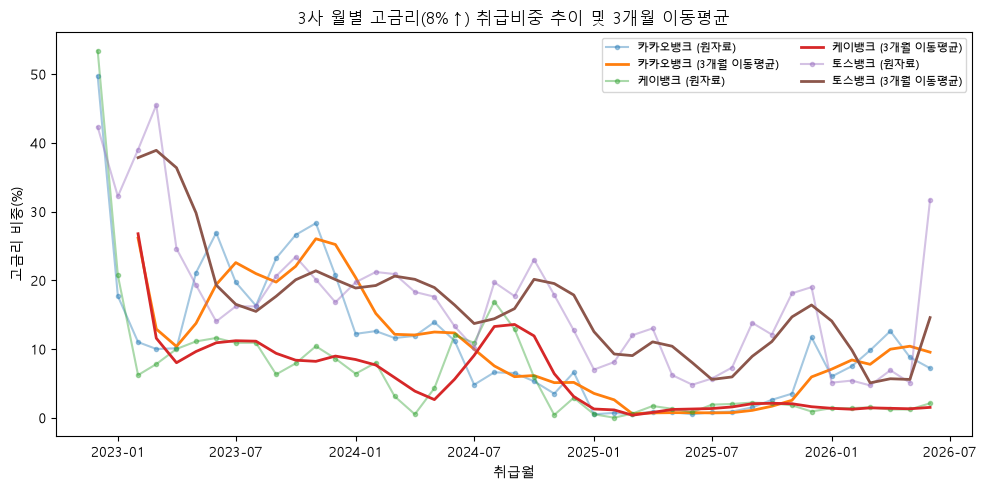

In [13]:
# 시각화 2: 질문 2 - 3사 고금리 비중 추이 + 3개월 이동평균
fig, ax = plt.subplots(figsize=(10, 5))
for bank in df_rate_wide.columns:
    ax.plot(df_rate_wide.index, df_rate_wide[bank], marker='o', markersize=3, alpha=0.4, label=f'{bank} (원자료)')
    ax.plot(df_rate_ma.index, df_rate_ma[bank], linewidth=2, label=f'{bank} (3개월 이동평균)')
ax.set_title('3사 월별 고금리(8%↑) 취급비중 추이 및 3개월 이동평균')
ax.set_xlabel('취급월')
ax.set_ylabel('고금리 비중(%)')
ax.legend(fontsize=8, ncol=2)
plt.tight_layout()
plt.savefig('images/02_high_rate_share_trend.png', dpi=150)
plt.show()


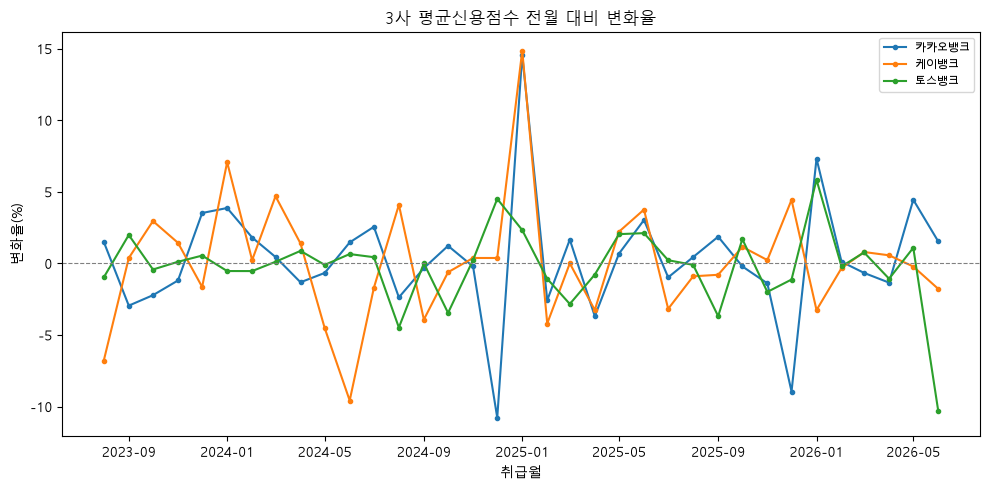

In [14]:
# 시각화 3: 질문 3-1 - 신용점수 전월 대비 변화율
fig, ax = plt.subplots(figsize=(10, 5))
for bank in df_credit_pct.columns:
    ax.plot(df_credit_pct.index, df_credit_pct[bank], marker='o', markersize=3, label=bank)
ax.axhline(0, color='gray', linewidth=0.8, linestyle='--')
ax.set_title('3사 평균신용점수 전월 대비 변화율')
ax.set_xlabel('취급월')
ax.set_ylabel('변화율(%)')
ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig('images/03_credit_score_pct_change.png', dpi=150)
plt.show()


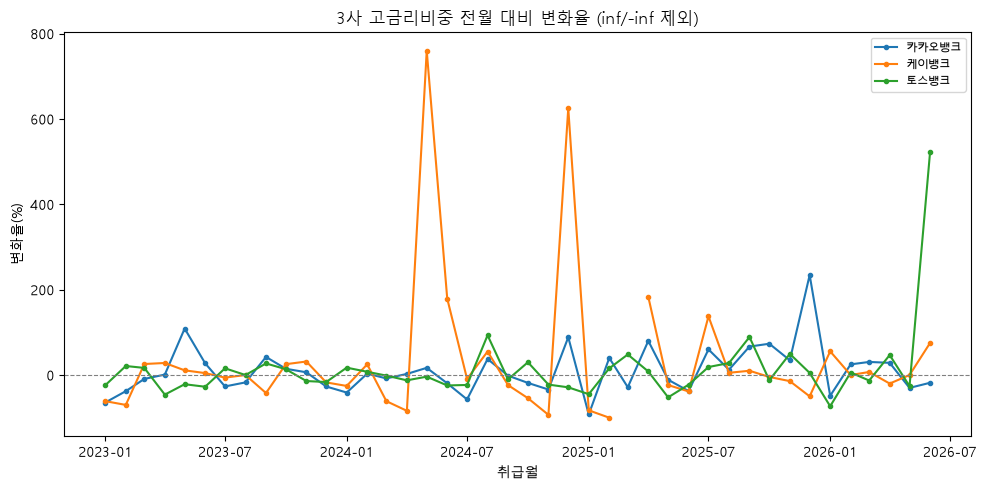

In [15]:
# 시각화 4: 질문 3-2 - 고금리비중 전월 대비 변화율 (inf 제외)
fig, ax = plt.subplots(figsize=(10, 5))
for bank in df_rate_pct.columns:
    ax.plot(df_rate_pct.index, df_rate_pct[bank], marker='o', markersize=3, label=bank)
ax.axhline(0, color='gray', linewidth=0.8, linestyle='--')
ax.set_title('3사 고금리비중 전월 대비 변화율 (inf/-inf 제외)')
ax.set_xlabel('취급월')
ax.set_ylabel('변화율(%)')
ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig('images/04_high_rate_pct_change.png', dpi=150)
plt.show()


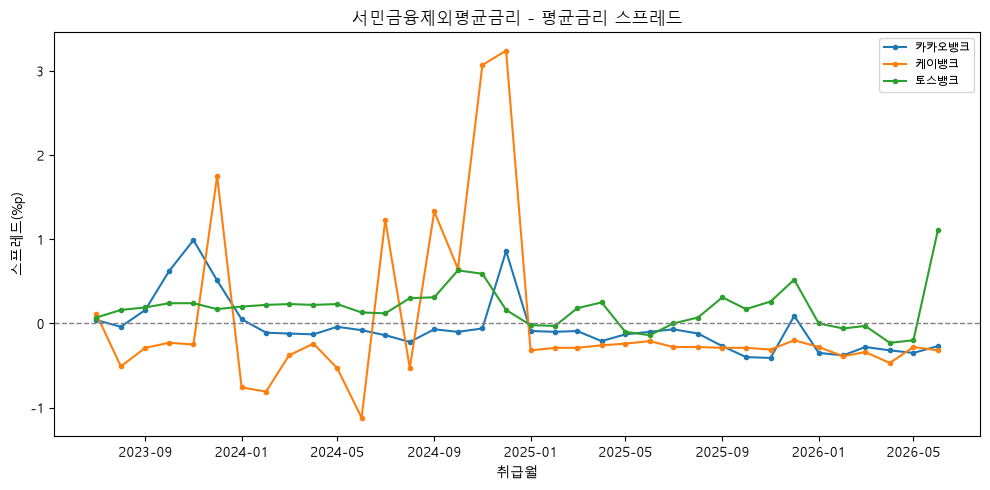

In [16]:
# 시각화 5: 질문 4 - 서민금융제외평균금리-평균금리 스프레드
fig, ax = plt.subplots(figsize=(10, 5))
for bank in df_spread_wide.columns:
    ax.plot(df_spread_wide.index, df_spread_wide[bank], marker='o', markersize=3, label=bank)
ax.axhline(0, color='gray', linestyle='--', linewidth=1)
ax.set_title('서민금융제외평균금리 - 평균금리 스프레드')
ax.set_xlabel('취급월')
ax.set_ylabel('스프레드(%p)')
ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig('images/05_spread_trend.png', dpi=150)
plt.show()


## 6. 인사이트 검증용 수치 확인
- REPORT.md 본문에 적은 구체적 수치(변화율, 시작·종료값 등)를 실제 코드 출력과 대조하는 셀

In [17]:
# 은행별 시작/종료/최저/최고 신용점수
for bank in df_credit_wide.columns:
    s = df_credit_wide[bank].dropna()
    print(f"{bank}: 시작={s.iloc[0]:.0f} 종료={s.iloc[-1]:.0f} 최저={s.min():.0f} 최고={s.max():.0f}")


카카오뱅크: 시작=867 종료=931 최저=811 최고=931
케이뱅크: 시작=869 종료=880 최저=802 최고=951
토스뱅크: 시작=918 종료=834 최저=834 최고=937


In [18]:
# 고금리비중 변화율 상위 급등/급락 구간 (케이뱅크 등 검증용)
for bank in df_rate_pct.columns:
    print(f"--- {bank} ---")
    print(df_rate_pct[bank].dropna().sort_values(ascending=False).head(3))
    print(df_rate_pct[bank].dropna().sort_values().head(3))
    print()


--- 카카오뱅크 ---
취급월
2025-12-01    234.285714
2023-05-01    108.910891
2024-12-01     88.571429
Name: 카카오뱅크, dtype: float64
취급월
2025-01-01   -92.424242
2023-01-01   -64.386318
2024-07-01   -57.142857
Name: 카카오뱅크, dtype: float64

--- 케이뱅크 ---
취급월
2024-05-01    760.000000
2024-12-01    625.000000
2025-04-01    183.333333
Name: 케이뱅크, dtype: float64
취급월
2025-02-01   -100.000000
2024-11-01    -93.220339
2024-04-01    -83.870968
Name: 케이뱅크, dtype: float64

--- 토스뱅크 ---
취급월
2026-06-01    521.568627
2024-08-01     93.137255
2025-09-01     89.041096
Name: 토스뱅크, dtype: float64
취급월
2026-01-01   -73.157895
2025-05-01   -52.307692
2023-04-01   -45.934066
Name: 토스뱅크, dtype: float64



In [19]:
# 토스뱅크 2026-06 스냅샷 (인사이트 3 근거 수치 확인)
snap = df_credit[(df_credit['은행']=='토스뱅크') & (df_credit['취급월']>='2026-04')]
print(snap[['취급월','평균금리','서민금융제외평균금리','평균신용점수','스프레드']].to_string(index=False))

snap_rate = df_rate[(df_rate['은행']=='토스뱅크') & (df_rate['취급월']>='2026-04')]
print()
print(snap_rate[['취급월','고금리8퍼센트이상비중']].to_string(index=False))


       취급월  평균금리  서민금융제외평균금리  평균신용점수  스프레드
2026-04-01  5.72        5.49     920 -0.23
2026-05-01  5.66        5.46     930 -0.20
2026-06-01  7.80        8.91     834  1.11

       취급월  고금리8퍼센트이상비중
2026-04-01          6.9
2026-05-01          5.1
2026-06-01         31.7
